In [1]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import equinox as eqx
import json

import matplotlib.pyplot as plt

from models import HamiltonianNN, NeuralODE
from vector_fields import vector_field_three_body_plummer, vector_field_three_body_repulsive, vector_field_hnn_potenergy, vector_field_hnn_totenergy, vector_field_node_vanilla, vector_field_node_phys
from utilities import Params, integrate_vector_field, to_canonical, split_train_val, save_model, load_model
from train import train_partially_observed, train_fully_observed

In [3]:
seed = 0
key = jax.random.PRNGKey(seed)

In [4]:
def zero_total_momentum(v, masses):
    """
    v: array (..., n_bodies, dim) velocities
    masses: array (n_bodies,)
    returns v' with sum_i m_i v'_i = 0
    """
    M = jnp.sum(masses)
    V_cm = jnp.tensordot(masses, v, axes=(0, -2)) / M   # (..., dim)
    return v - V_cm[... , None, :] 

In [5]:
def sample_ic_batch(key: jax.random.PRNGKey, system_params: Params, N: int):
    """
    Samples initial conditions for the 3D triangular 3-mass system.

    Returns shape (N, 18):
    [x0, y0, z0, x1, y1, z1, x2, y2, z2,
     vx0, vy0, vz0, vx1, vy1, vz1, vx2, vy2, vz2]
    """
    masses = jnp.array([system_params.m0, system_params.m1, system_params.m2])

    # Split keys
    key0, key1, key2, key3, keyz = jax.random.split(key, 5)

    # --- Base triangular layout (roughly upright triangle in x–y) ---

    # Mass 0 near top
    x0 = jax.random.uniform(key0, (N,), minval=0.3, maxval=0.7)
    y0 = jax.random.uniform(key0, (N,), minval=1.0, maxval=1.4)

    # Mass 1 bottom-left region
    x1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.4)
    y1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.5)

    # Mass 2 bottom-right region
    x2 = jax.random.uniform(key2, (N,), minval=0.6, maxval=0.9)
    y2 = jax.random.uniform(key2, (N,), minval=0.1, maxval=0.5)

    # z-coordinates: small perturbations around 0 (near a plane)
    z0 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z1 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z2 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)

    # Stack positions: (N, 9)
    r = jnp.stack([x0, y0, z0,
                   x1, y1, z1,
                   x2, y2, z2], axis=-1)

    # Recenter center of mass to origin
    r_reshaped = r.reshape(N, 3, 3)               # (N, n_bodies, dim)
    total_mass = jnp.sum(masses)
    r_cm = (masses[None, :, None] * r_reshaped).sum(axis=1, keepdims=True) / total_mass
    r_reshaped = r_reshaped - r_cm                # shift COM to origin
    r = r_reshaped.reshape(N, 9)

    # Zero total momentum
    v = jax.random.uniform(key3, (N, 9), minval=-0.3, maxval=0.3)
    v_reshaped = v.reshape(N, 3, 3)
    v_zero = jax.vmap(zero_total_momentum, in_axes=(0, None))(v_reshaped, masses)
    v = v_zero.reshape(N, 9)

    # Return concatenated state: (N, 18)
    return jnp.concatenate([r, v], axis=-1)

In [7]:
system_params = Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)
trajectory_length = 1.0
trajectory_steps = 1001
n_trajectories = 4000
eps=1e-1

ts = jnp.linspace(0.0, trajectory_length, trajectory_steps)

y0s = sample_ic_batch(key, system_params, n_trajectories)

solve_batch = integrate_vector_field(ts=ts, term=vector_field_three_body_plummer, eps=eps)
ys_all = solve_batch(model=None, params=system_params, y0s=y0s)   # (N, T, 6)
print("ys_all:", ys_all.shape)


# plt.figure()
# for i in range(ys_all.shape[0]):
#     plt.plot(ts, ys_all[i, :, 0], alpha=0.3, color='black', lw=0.3)  # x0
# plt.title('Position of mass 0 over time for 2000 samples')
# plt.xlabel('Time')
# plt.ylabel('Position x0')
# plt.show()

ys_all: (4000, 1001, 18)


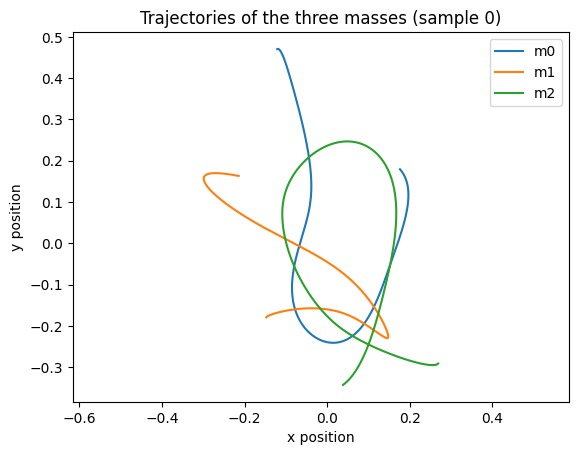

In [8]:
plt.plot(ys_all[3, :, 0], ys_all[3, :, 1], label='m0')
plt.plot(ys_all[3, :, 3], ys_all[3, :, 4], label='m1')
plt.plot(ys_all[3, :, 6], ys_all[3, :, 7], label='m2')
plt.title('Trajectories of the three masses (sample 0)')
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend()
plt.axis('equal')
plt.show()

### Initialize neural networks

In [9]:
hidden_dim = 128
depth = 4
relative_distances = True

In [10]:
key, subkey = jax.random.split(key)
hnn_potenergy = HamiltonianNN(key=subkey, input_dim=9, hidden_dim=hidden_dim, depth=depth, relative_distances=relative_distances)
hnn_potenergy_params, hnn_potenergy_static = eqx.partition(hnn_potenergy, eqx.is_array)

key, subkey = jax.random.split(key)
hnn_totenergy = HamiltonianNN(key=subkey, input_dim=18, hidden_dim=hidden_dim, relative_distances=relative_distances)
hnn_totenergy_params, hnn_totenergy_static = eqx.partition(hnn_totenergy, eqx.is_array)

key, subkey = jax.random.split(key)
node_phys = NeuralODE(key=subkey, input_dim=18, hidden_dim=64, output_dim=9, relative_distances=True)
node_phys_params, node_phys_static = eqx.partition(node_phys, eqx.is_array)

key, subkey = jax.random.split(key)
node_vanilla = NeuralODE(key=subkey, input_dim=18, hidden_dim=64, output_dim=18, relative_distances=True)
node_vanilla_params, node_vanilla_static = eqx.partition(node_vanilla, eqx.is_array)

In [11]:
ys_can = to_canonical(ys_all, system_params.m0, system_params.m1, system_params.m2)

train_fraction = 0.85

key, subkey = jax.random.split(key)
train_all, val_all = split_train_val(subkey, ys_can, train_fraction)

### Train HNN model 1 (learning potential energy)

In [11]:
system_params

Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)

In [12]:
batch_size = 64
epochs = 1
learning_rate = 1e-3
lr_schedule={
    'type': 'exponential_decay',
    'decay_rate': 0.95,     
    'decay_epochs': 10     
}

In [13]:
run_hnn_potenergy = integrate_vector_field(ts, term=vector_field_hnn_potenergy, eps=eps)
hnn_potenergy_params, hnn_potenergy_static, losses = train_partially_observed(
    batch_size=batch_size, 
    epochs=epochs, 
    key=subkey, 
    run_hnn=run_hnn_potenergy, 
    system_params=system_params, 
    model_params=hnn_potenergy_params, 
    model_static=hnn_potenergy_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=learning_rate,
    lr_schedule=lr_schedule
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/1 | Train Loss: 0.257369 | Val Loss: 0.206366 | LR: 1.00e-03

Training complete!


In [15]:
run_hnn_totenergy = integrate_vector_field(ts, term=vector_field_hnn_totenergy)
hnn_totenergy_params, hnn_totenergy_static, losses = train_partially_observed(
    batch_size=batch_size, 
    epochs=epochs, 
    key=subkey, 
    run_hnn=run_hnn_totenergy, 
    system_params=system_params, 
    model_params=hnn_totenergy_params, 
    model_static=hnn_totenergy_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=learning_rate,
    lr_schedule=lr_schedule
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/1 | Train Loss: 0.314805 | Val Loss: 0.267643 | LR: 1.00e-03

Training complete!


In [16]:
run_node_phys = integrate_vector_field(ts, term=vector_field_node_phys)
node_params, node_static, losses = train_partially_observed(
    batch_size=batch_size,
    epochs=epochs, 
    key=subkey, 
    run_hnn=run_node_phys, 
    system_params=system_params, 
    model_params=node_phys_params, 
    model_static=node_phys_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=learning_rate,
    lr_schedule=lr_schedule
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/1 | Train Loss: 0.324667 | Val Loss: 0.270932 | LR: 1.00e-03

Training complete!


In [17]:
run_node_vanilla = integrate_vector_field(ts, term=vector_field_node_vanilla)
node_vanilla_params, node_vanilla_static, losses = train_partially_observed(
    batch_size=batch_size,
    epochs=epochs, 
    key=subkey, 
    run_hnn=run_node_vanilla, 
    system_params=system_params, 
    model_params=node_vanilla_params, 
    model_static=node_vanilla_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=learning_rate,
    lr_schedule=lr_schedule
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/1 | Train Loss: 0.321595 | Val Loss: 0.266379 | LR: 1.00e-03

Training complete!


### Save models

In [14]:
save_dir = f"checkpoints/epsilon_range_test/eps_{eps:.1f}".replace(".", "-") + "/"

In [15]:
# Save metadata
metadata = {
    "model_type": 'hnn',
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "lr_schedule": lr_schedule,
    "hidden_dim": hidden_dim,
    "depth": depth,
    "relative_distances": relative_distances,
    "system_params": {
        "m0": float(system_params.m0),
        "m1": float(system_params.m1),
        "m2": float(system_params.m2),
        "G": float(system_params.G),
    },
    "n_trajectories": n_trajectories,
    "trajectory_length": trajectory_length,
    "trajectory_steps": trajectory_steps,
    "train_fraction": train_fraction,
    "seed": seed,
}

In [18]:
# import json
# metadata_path = save_dir + "metadata.json"
# with open(metadata_path, "w") as f:
#         json.dump(metadata, f, indent=2)

In [ ]:
# import yaml
# import os
# from pathlib import Path

# config_path = Path(os.path.join(save_dir, "config.yaml"))
# with config_path.open("w") as f:
#     yaml.safe_dump(metadata, f, sort_keys=False)

In [ ]:
hnn_model_final_potenergy   = eqx.combine(hnn_potenergy_params, hnn_potenergy_static) #hnn_model_pot
#hnn_model_final_totenergy = eqx.combine(hnn_totenergy_params, hnn_totenergy_static) #hnn_model_tot
#node_model_final  = eqx.combine(node_params, node_static) #node_model
# # ##
save_model("hnn_potenergy_three_body", save_dir, hnn_model_final_potenergy, aux={"system_params": system_params})
#save_model("hnn_totenergy_three_body_rel_distance_300ep_lr_decay", "checkpoints/radius_1-0/absolute_positions/2025-11-25", hnn_model_final_totenergy, aux={"system_params": system_params})
#save_model("node_triangular_mass_spring_abs_pos_400ep_lr_decay", "checkpoints/spring_constant_0-05/absolute_positions/2025-11-20", node_model_final, aux={"system_params": system_params})